In [21]:
import tifffile as tiff
import rasterio
import numpy as np
import matplotlib.pyplot as plt

### Importer et visualiser l'image de segmentation (output du modèle)

Dimensions: (5000, 5000)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.01477928
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 24630518 pixels
Classe 1: 369482 pixels


c:\Users\sinadeau\AppData\Local\miniconda3\envs\ML_3.12.7\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


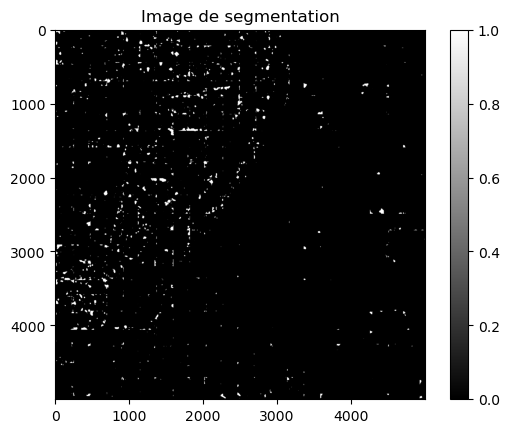

In [27]:
# Ouvrir image de segmentation
with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463.tif") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(segmentation)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(segmentation, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

# Normaliser entre 0 et 255
segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463_fixed.tif", "w", driver="GTiff",
                   height=segmentation.shape[0], width=segmentation.shape[1],
                   count=1, dtype=segmentation_normalized.dtype) as dst:
    dst.write(segmentation_normalized, 1)


#visualiser l'image de segmentation
plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()


## Importer l'image de ground truth (labels)



Dimensions: (1271, 1014)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.3187701060060801
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 877965 pixels
Classe 1: 410829 pixels


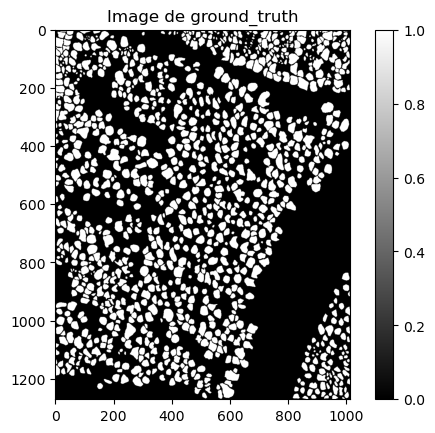

In [ ]:
# Ouvrir image de Ground Truth
with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/ground_truth_2018_1km_6294_463.png") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    ground_truth = src.read(1)

# Statistiques de l’image
print(f"Min: {ground_truth.min()}, Max: {ground_truth.max()}, Moyenne: {ground_truth.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(ground_truth)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(ground_truth, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

# Normaliser entre 0 et 255
ground_truth_normalized = (ground_truth - ground_truth.min()) / (ground_truth.max() - ground_truth.min()) * 255
ground_truth_normalized = ground_truth_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463_fixed.tif", "w", driver="GTiff",
                   height=ground_truth.shape[0], width=ground_truth.shape[1],
                   count=1, dtype=ground_truth_normalized.dtype) as dst:
    dst.write(ground_truth_normalized, 1)


#visualiser l'image de labels
plt.imshow(ground_truth, cmap="gray")
plt.colorbar()
plt.title("Image de ground_truth")
plt.show()

## Merger les images de ground truth et de segmentation


In [ ]:
import geopandas as gpd
from shapely.geometry import box


# Charger les fichiers vecteurs (exemple)
ground_truth_gdf = gpd.read_file("ground_truth_vector.shp")
segmentation_gdf = gpd.read_file("segmentation_vector.shp")

# Effectuer l'intersection
intersection = gpd.overlay(ground_truth_gdf, segmentation_gdf, how='intersection')

# Visualiser l'intersection
intersection.plot()
plt.title("Intersection entre ground_truth et segmentation")
plt.show()

ValueError: operands could not be broadcast together with shapes (1271,1014) (5000,5000) 

## Test pour calculer une métrique

In [26]:
from sklearn.metrics import accuracy_score

def eva_acc(y_true, y_label):
    
    return accuracy_score(y_true.flatten(), y_label.flatten())

eva_acc(ground_truth, segmentation_normalized)

ValueError: Found input variables with inconsistent numbers of samples: [1288794, 25000000]